# Optimize CN3S Model

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import pandas as pd

from cn3s import CN3S, CN3SOptimizer, CN3SParams
from utils import load_data

## Load Data

In [2]:
BASIN = "RioBranco"

data = load_data(BASIN, "M")
data.keys()

dict_keys(['station', 'area', 'prec', 'q', 'shp'])

## Run Optimizer

In [3]:
from cn3s.objectives import Objectives

In [11]:
params = CN3SParams(name="Rio Branco (13600002)", area=data["area"], warmup_steps=3)
model = CN3S(params)

optim = CN3SOptimizer(
    prec=data["prec"]["prec"],
    observed_q=data["q"]["Vazao"],
    model=model,
    train_ratio=0.8,
    max_act=5,
    objective=Objectives.NSETopBlend,
)

print(f"Aligned record: {len(optim.aligned)} time steps")
print(f"Train: {optim.train_idx} | Test: {len(optim.aligned) - optim.train_idx}")

Aligned record: 314 time steps
Train: 251 | Test: 63


In [12]:
# Interrupt at any time — optim.model will hold the best parameters seen so far.
optim.optimize(maxiter=500, tol=1e-4, disp=False, workers=-1)

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_differentialevolution.py:487: UserWarning:

differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'



1 - Train objective: 15.3195
2 - Train objective: 15.2463
3 - Train objective: 15.1567
4 - Train objective: 15.1567
5 - Train objective: 15.1318
6 - Train objective: 15.0874
7 - Train objective: 2.1723
8 - Train objective: 2.1723
9 - Train objective: 2.1723
10 - Train objective: 2.1723
11 - Train objective: 1.2365
12 - Train objective: 1.2365
13 - Train objective: 1.2032
14 - Train objective: 0.9209
15 - Train objective: 0.9209
16 - Train objective: 0.9209
17 - Train objective: 0.9209
18 - Train objective: 0.9209
19 - Train objective: 0.9209
20 - Train objective: 0.9209
21 - Train objective: 0.9209
22 - Train objective: 0.8507
23 - Train objective: 0.8507
24 - Train objective: 0.8321
25 - Train objective: 0.8321
26 - Train objective: 0.7510
27 - Train objective: 0.7510
28 - Train objective: 0.7307
29 - Train objective: 0.7307
30 - Train objective: 0.7277
31 - Train objective: 0.7277
32 - Train objective: 0.7277
33 - Train objective: 0.7116
34 - Train objective: 0.7116
35 - Train object

## Evaluate Results

In [13]:
optim.evaluate_step(127)

{'train_objective': 0.6941001802846509,
 'test_objective': 2.4821311183573775,
 'train_nse': 0.4319090456073077,
 'test_nse': 0.48322018061164607}

In [14]:
model.evaluate(data["q"]["Vazao"])
model.plot(split=251)

Aligned 311 time steps between model results and observations.
From 2000-04-01 00:00:00 to 2026-02-01 00:00:00.


In [ ]:
model.evaluate(data["q"]["Vazao"])
model.plot(split=200)

Aligned 311 time steps between model results and observations.
From 2000-04-01 00:00:00 to 2026-02-01 00:00:00.


In [17]:
# Split index (adjusted for 3-month warm-up)
split = optim.train_idx - optim._n_warmup

train_nse = r2_score(results.iloc[:split]["observed_q"], results.iloc[:split]["q_m3s"])
test_nse = r2_score(results.iloc[split:]["observed_q"], results.iloc[split:]["q_m3s"])

print(f"Train NSE: {train_nse:.4f}")
print(f"Test  NSE: {test_nse:.4f}")

Train NSE: 0.8219
Test  NSE: 0.7739


Text(0, 0.5, 'Discharge (m³/s)')

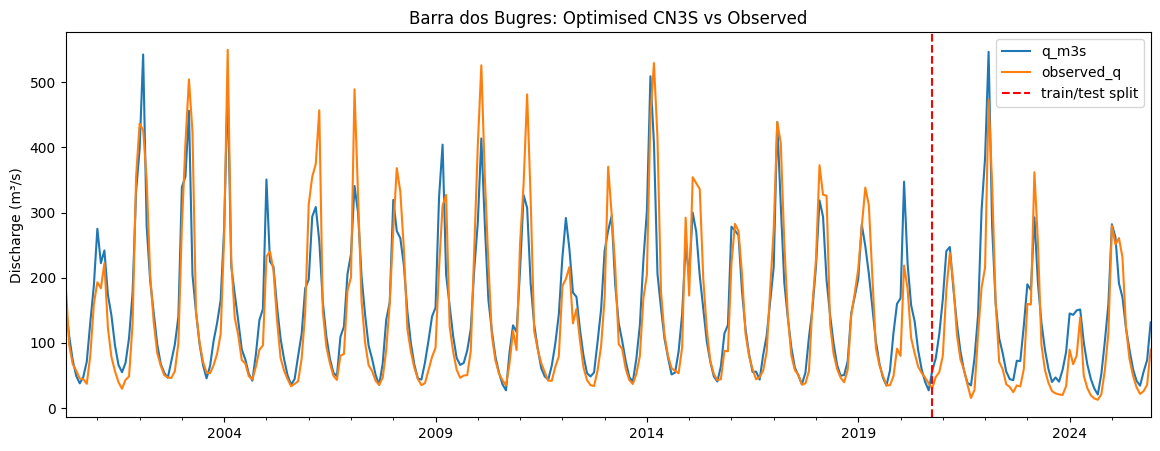

In [25]:
ax = results.plot(y=["q_m3s", "observed_q"], figsize=(14, 5), title="Barra dos Bugres: Optimised CN3S vs Observed")
ax.axvline(results.index[split], color="red", linestyle="--", label="train/test split")
ax.legend()
ax.set_ylabel("Discharge (m³/s)")

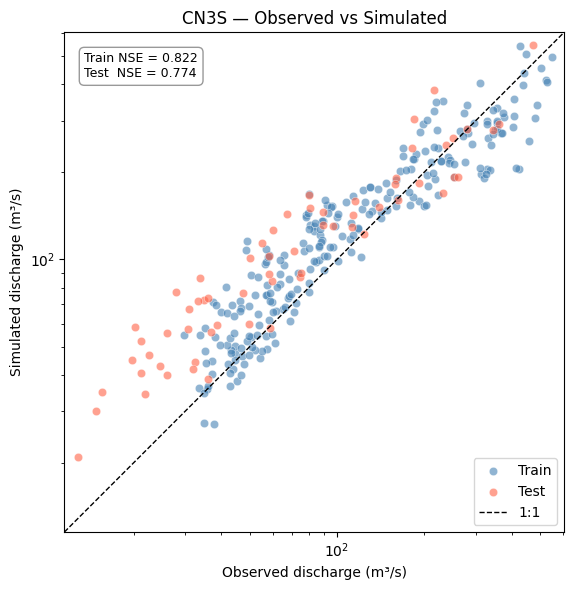

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 6))

# Train and test points with distinct colours
ax.scatter(
    results.iloc[:split]["observed_q"],
    results.iloc[:split]["q_m3s"],
    alpha=0.6,
    label="Train",
    color="steelblue",
    edgecolors="white",
    linewidths=0.4,
)
ax.scatter(
    results.iloc[split:]["observed_q"],
    results.iloc[split:]["q_m3s"],
    alpha=0.6,
    label="Test",
    color="tomato",
    edgecolors="white",
    linewidths=0.4,
)

ax.set_xscale("log")
ax.set_yscale("log")

# 1:1 line spanning the full data range (log-safe: use positive values only)
all_vals = pd.concat([results["observed_q"], results["q_m3s"]])
all_vals = all_vals[all_vals > 0]
lims = [all_vals.min() * 0.9, all_vals.max() * 1.1]
ax.plot(lims, lims, "k--", linewidth=1, label="1:1")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")

ax.set_xlabel("Observed discharge (m³/s)")
ax.set_ylabel("Simulated discharge (m³/s)")
ax.set_title("CN3S — Observed vs Simulated")

# NSE annotation box (top-left)
textstr = f"Train NSE = {train_nse:.3f}\nTest  NSE = {test_nse:.3f}"
ax.text(
    0.04,
    0.96,
    textstr,
    transform=ax.transAxes,
    verticalalignment="top",
    bbox={"boxstyle": "round,pad=0.4", "facecolor": "white", "edgecolor": "grey", "alpha": 0.8},
    fontsize=9,
)

ax.legend(loc="lower right")
plt.tight_layout()

In [19]:
# Calibrated parameters
optim.model.params

CN3SParams(area=9642, r0=98.95846565107985, cn_i=9.048392320346426, alfa=0.19965320663305813, beta=0.003796888013248299, k0=0.5528689602670063, k1=0.3312926383090628, k2=0.3332066544700027)